In [1]:
import numpy
print(numpy.__version__)


1.26.4


In [2]:
# Sentiment Analysis Pipeline Example (using 'claim' and 'label')
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
import re
import json
import os
import openai
import joblib
# Concurrency + progress helpers for embedding generation
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
# from dotenv import load_dotenv

# load_dotenv()
# OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

In [3]:
# 1. Load Data from JSONL files (using 'claim' and 'label')
def load_jsonl(path):
    with open(path, 'r') as f:
        return [json.loads(line) for line in f]

def jsonl_to_df(path):
    data = load_jsonl(path)
    return pd.DataFrame(data)[['claim', 'label']]

train_df = jsonl_to_df('/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/Liar-Plus-Recreation/Data/LIAR+ datasets/train2.jsonl')
val_df = jsonl_to_df('/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/Liar-Plus-Recreation/Data/LIAR+ datasets/val2.jsonl')
test_df = jsonl_to_df('/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/Liar-Plus-Recreation/Data/LIAR+ datasets/test2.jsonl')

In [4]:
# 2. Sentiment Labeling Function
def get_sentiment(text):
    positive_words = ['good', 'great', 'excellent', 'positive', 'success', 'happy', 'love', 'fortunate', 'correct', 'benefit']
    negative_words = ['bad', 'terrible', 'poor', 'negative', 'sad', 'hate', 'unfortunate', 'wrong', 'harm', 'fail']
    text_lower = str(text).lower()
    pos = sum(word in text_lower for word in positive_words)
    neg = sum(word in text_lower for word in negative_words)
    if pos > neg:
        return 'positive'
    elif neg > pos:
        return 'negative'
    else:
        return 'neutral'

for df in [train_df, val_df, test_df]:
    df['sentiment'] = df['claim'].apply(get_sentiment)

In [5]:
import os
from openai import OpenAI

# Grab the API key from the venv environment
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

def get_embedding(text: str, api_key: str = OPENROUTER_API_KEY, model: str = "google/gemini-embedding-001") -> list[float]:
    if not api_key:
        raise ValueError("API key not found. Make sure your venv is activated and OPENROUTER_API_KEY is set.")

    client = OpenAI(
        base_url="https://openrouter.ai/api/v1",
        api_key=api_key,
    )

    embedding = client.embeddings.create(
        model=model,
        input=text,
        encoding_format="float"
    )
    return embedding.data[0].embedding

# Quick smoke test (remove or comment out when running large batches)
# print(get_embedding("Hello, world!"))


In [6]:
# 4. Generate Embeddings
def embed_column(df: pd.DataFrame, column: str, api_key: str = OPENROUTER_API_KEY, model: str = "google/gemini-embedding-001", max_workers: int = 10) -> pd.DataFrame:
    df_result = df.copy()
    texts = df[column].astype(str).tolist()
    def embed_single(text):
        try:
            return get_embedding(text, api_key=api_key, model=model)
        except Exception as e:
            print(f"Exception on: {text[:50]} -- {str(e)}")
            return None
    
    embeddings = [None] * len(texts)
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_idx = {executor.submit(embed_single, text): idx for idx, text in enumerate(texts)}
        for future in tqdm(as_completed(future_to_idx), total=len(texts), desc=f"Embedding {column}"):
            idx = future_to_idx[future]
            embedding = future.result()
            embeddings[idx] = embedding
    
    embedding_dim = None
    for emb in embeddings:
        if emb is not None:
            embedding_dim = len(emb)
            break
    
    if embedding_dim is None:
        raise ValueError("No successful embeddings found")
    for dim in range(embedding_dim):
        col_name = f"{column}_embedding_{dim}"
        df_result[col_name] = [emb[dim] if emb is not None else np.nan for emb in embeddings]
    
    return df_result

# NOTE: columns created by this function use the prefix '<column>_embedding_<dim>'
# e.g., for claims the columns will be 'claim_embedding_0', 'claim_embedding_1', ...


In [7]:
# 4b. Generate embeddings for train/validation/test with sampling and optional caching.
# This avoids generating embeddings for the entire training set (which can be very slow/expensive).
import os
import pandas as pd
import numpy as np

# Configuration: set sample size for train split and whether to enable caching
TRAIN_SAMPLE_SIZE = 2000  # number of training rows to embed (lower for faster runs)
ENABLE_CACHE = True
CACHE_DIR = os.path.join(os.getcwd(), 'embeddings_cache')
os.makedirs(CACHE_DIR, exist_ok=True)

def _cache_path(split_name: str) -> str:
    return os.path.join(CACHE_DIR, f"{split_name}_claim_embeddings.pkl")

print(f"Embedding config — train_sample_size={TRAIN_SAMPLE_SIZE}, cache_enabled={ENABLE_CACHE}, cache_dir={CACHE_DIR}")

# Helper: merge embedding columns efficiently
def _merge_embeddings(target_df: pd.DataFrame, embedded_df: pd.DataFrame, column_prefix: str = 'claim_embedding_') -> pd.DataFrame:
    embedding_cols = [c for c in embedded_df.columns if c.startswith(column_prefix)]
    if not embedding_cols:
        return target_df
    # Merge all embedding columns at once
    return pd.concat([target_df, embedded_df[embedding_cols]], axis=1)

# Helper: convert list of embeddings into a DataFrame with proper column names
def _embeddings_to_df(df: pd.DataFrame, embeddings: list, prefix: str = 'claim_embedding_') -> pd.DataFrame:
    if len(embeddings) == 0:
        return pd.DataFrame(index=df.index)
    
    embedding_dim = len(embeddings[0]) if embeddings[0] is not None else 0
    embeddings_array = np.array([emb if emb is not None else [np.nan]*embedding_dim for emb in embeddings])
    
    columns = [f"{prefix}{i}" for i in range(embedding_dim)]
    return pd.DataFrame(embeddings_array, columns=columns, index=df.index)

# --- TRAIN (sampled) ---
train_cache = _cache_path('train')
if ENABLE_CACHE and os.path.exists(train_cache):
    print('Loading cached train embeddings...')
    train_embedded = pd.read_pickle(train_cache)
    train_df = _merge_embeddings(train_df, train_embedded)
else:
    if len(train_df) > TRAIN_SAMPLE_SIZE:
        print(f"Dataset is large ({len(train_df)} rows). Sampling {TRAIN_SAMPLE_SIZE} rows for embeddings.")
        train_sample = train_df.sample(n=TRAIN_SAMPLE_SIZE, random_state=42)
    else:
        print(f"Dataset is small ({len(train_df)} rows). Embedding full training set.")
        train_sample = train_df.copy()

    # Generate embeddings for the sampled subset
    train_embeddings = embed_column(train_sample, 'claim', api_key=OPENROUTER_API_KEY)
    train_embedded_df = _embeddings_to_df(train_sample, train_embeddings)
    train_df = _merge_embeddings(train_df, train_embedded_df)

    if ENABLE_CACHE:
        print('Caching train embeddings...')
        pd.to_pickle(train_embedded_df, train_cache)

# --- VAL ---
val_cache = _cache_path('val')
if ENABLE_CACHE and os.path.exists(val_cache):
    print('Loading cached val embeddings...')
    val_embedded = pd.read_pickle(val_cache)
    val_df = _merge_embeddings(val_df, val_embedded)
else:
    print('Generating embeddings for validation set...')
    val_embeddings = embed_column(val_df, 'claim', api_key=OPENROUTER_API_KEY)
    val_embedded_df = _embeddings_to_df(val_df, val_embeddings)
    val_df = _merge_embeddings(val_df, val_embedded_df)
    if ENABLE_CACHE:
        pd.to_pickle(val_embedded_df, val_cache)

# --- TEST ---
test_cache = _cache_path('test')
if ENABLE_CACHE and os.path.exists(test_cache):
    print('Loading cached test embeddings...')
    test_embedded = pd.read_pickle(test_cache)
    test_df = _merge_embeddings(test_df, test_embedded)
else:
    print('Generating embeddings for test set...')
    test_embeddings = embed_column(test_df, 'claim', api_key=OPENROUTER_API_KEY)
    test_embedded_df = _embeddings_to_df(test_df, test_embeddings)
    test_df = _merge_embeddings(test_df, test_embedded_df)
    if ENABLE_CACHE:
        pd.to_pickle(test_embedded_df, test_cache)

print('Embedding generation (sampled for train) complete.\n'
      'Remember: train_df contains embeddings only for the sampled rows; other rows remain NaN unless you embed them later.')


Embedding config — train_sample_size=2000, cache_enabled=True, cache_dir=/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/model_training_scripts/sentiment_analysis/embeddings_cache
Loading cached train embeddings...
Loading cached val embeddings...
Loading cached test embeddings...
Loading cached val embeddings...
Loading cached test embeddings...
Embedding generation (sampled for train) complete.
Remember: train_df contains embeddings only for the sampled rows; other rows remain NaN unless you embed them later.
Embedding generation (sampled for train) complete.
Remember: train_df contains embeddings only for the sampled rows; other rows remain NaN unless you embed them later.


In [8]:
# 5. Encode Sentiment Labels
le = LabelEncoder()
train_df['sentiment_label'] = le.fit_transform(train_df['sentiment'])
val_df['sentiment_label'] = le.transform(val_df['sentiment'])
test_df['sentiment_label'] = le.transform(test_df['sentiment'])

/var/folders/lh/4mq6w_g54p5d9v09ngbytmzc0000gn/T/ipykernel_47795/1224571453.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df['sentiment_label'] = le.fit_transform(train_df['sentiment'])


In [9]:
# 5. Encode Sentiment Labels
le = LabelEncoder()
train_df['sentiment_label'] = le.fit_transform(train_df['sentiment'])
val_df['sentiment_label'] = le.transform(val_df['sentiment'])
test_df['sentiment_label'] = le.transform(test_df['sentiment'])

# 6. Prepare Features and Labels (use columns created by embed_column)
# embed_column creates columns like 'claim_embedding_0', 'claim_embedding_1', ...
embedding_prefix = 'claim_embedding_'
X_train = train_df[[col for col in train_df.columns if col.startswith(embedding_prefix)]].to_numpy()
y_train = train_df['sentiment_label'].to_numpy()
X_val = val_df[[col for col in val_df.columns if col.startswith(embedding_prefix)]].to_numpy()
y_val = val_df['sentiment_label'].to_numpy()
X_test = test_df[[col for col in test_df.columns if col.startswith(embedding_prefix)]].to_numpy()
y_test = test_df['sentiment_label'].to_numpy()

In [12]:
# --- 7. Train and Save XGBoost Sentiment Model ---
import xgboost as xgb
import os

# Target model directory (match runtime code in models/sentiment_analysis)
TARGET_MODEL_DIR = '/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/models/sentiment_analysis'
os.makedirs(TARGET_MODEL_DIR, exist_ok=True)

# Ensure you have embeddings generated (X_train not empty)
if X_train.size == 0:
    raise ValueError("Embedding features are empty — make sure embeddings are generated.")

# Define the model
xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=3,  # positive, neutral, negative
    eval_metric="mlogloss",
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    seed=42
)

# Fit model
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

# Evaluate
y_pred = xgb_model.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_val, y_pred, target_names=le.classes_))

# Save model as JSON for deployment (filename expected by runtime code)
import joblib

model_path = os.path.join(TARGET_MODEL_DIR, 'sentiment_model.gz')
joblib.dump(xgb_model, model_path, compress=3)
print(f"✅ Saved XGBoost sentiment model to {model_path}")

[0]	validation_0-mlogloss:0.57828
[1]	validation_0-mlogloss:0.53469
[1]	validation_0-mlogloss:0.53469
[2]	validation_0-mlogloss:0.49700
[2]	validation_0-mlogloss:0.49700
[3]	validation_0-mlogloss:0.46425
[3]	validation_0-mlogloss:0.46425
[4]	validation_0-mlogloss:0.43500
[4]	validation_0-mlogloss:0.43500
[5]	validation_0-mlogloss:0.40800
[5]	validation_0-mlogloss:0.40800
[6]	validation_0-mlogloss:0.38446
[6]	validation_0-mlogloss:0.38446
[7]	validation_0-mlogloss:0.36326
[7]	validation_0-mlogloss:0.36326
[8]	validation_0-mlogloss:0.34622
[8]	validation_0-mlogloss:0.34622
[9]	validation_0-mlogloss:0.33030
[9]	validation_0-mlogloss:0.33030
[10]	validation_0-mlogloss:0.31631
[10]	validation_0-mlogloss:0.31631
[11]	validation_0-mlogloss:0.30345
[11]	validation_0-mlogloss:0.30345
[12]	validation_0-mlogloss:0.29284
[12]	validation_0-mlogloss:0.29284
[13]	validation_0-mlogloss:0.28256
[13]	validation_0-mlogloss:0.28256
[14]	validation_0-mlogloss:0.27372
[14]	validation_0-mlogloss:0.27372
[15]

/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precisi

In [13]:
# 7. Train Multiple Classifiers (from muller_loop.ipynb)
classifiers = {
    "Random Forest": RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    "SVM": SVC(kernel="linear", C=0.025, probability=True),
    "Neural Net": MLPClassifier(alpha=1, max_iter=1000)
}

results = {}
try:
    for name, clf in classifiers.items():
        # Check if X_train and y_train are not empty
        if X_train.size == 0 or y_train.size == 0 or X_val.size == 0 or y_val.size == 0:
            print(f"Skipping {name}: Feature or label arrays are empty.")
            continue
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        report = classification_report(y_val, y_pred, target_names=le.classes_)
        results[name] = (acc, report)
        print(f"Classifier: {name}")
        print(f"Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(report)
        print("-" * 60)
except Exception as e:
    print(f"Error during classifier training: {e}")


Classifier: Random Forest
Accuracy: 0.9509
Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        23
     neutral       0.95      1.00      0.97      1221
    positive       0.00      0.00      0.00        40

    accuracy                           0.95      1284
   macro avg       0.32      0.33      0.32      1284
weighted avg       0.90      0.95      0.93      1284

------------------------------------------------------------
Error during classifier training: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html Yo

/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/danielbirman/Desktop/UCSD/Year 4/Fall 2025/DSC 180A/capstone_factuality_factors/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precisi

In [14]:
# 8. Emotional Trigger Analysis
def emotional_triggers(text):
    triggers = ['shocking', 'unbelievable', 'amazing', 'disaster', 'crisis', 'urgent', 'warning', 'exclusive', 'secret', 'revealed']
    found = [word for word in triggers if re.search(rf'\b{word}\b', str(text).lower())]
    return found

for df in [train_df, val_df, test_df]:
    df['emotional_triggers'] = df['claim'].apply(emotional_triggers)

print(train_df[['claim', 'sentiment', 'emotional_triggers']].head())

                                               claim sentiment  \
0  Says the Annies List political group supports ...   neutral   
1  When did the decline of coal start? It started...   neutral   
2  "Hillary Clinton agrees with John McCain ""by ...  positive   
3  Health care reform legislation is likely to ma...   neutral   
4  The economic turnaround started at the end of ...   neutral   

  emotional_triggers  
0                 []  
1                 []  
2                 []  
3                 []  
4                 []  


/var/folders/lh/4mq6w_g54p5d9v09ngbytmzc0000gn/T/ipykernel_47795/616936035.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['emotional_triggers'] = df['claim'].apply(emotional_triggers)


In [15]:
# 9. Sentiment vs Event Comparison
for idx, row in train_df.iterrows():
    if row['sentiment'] == 'positive' and 'crisis' in row['claim'].lower():
        print(f"Possible mismatch: {row['claim']} | Sentiment: {row['sentiment']}")

# The above code covers:
# - Sentiment prediction (positive/negative/neutral)
# - Emotional trigger detection
# - Sentiment vs event comparison

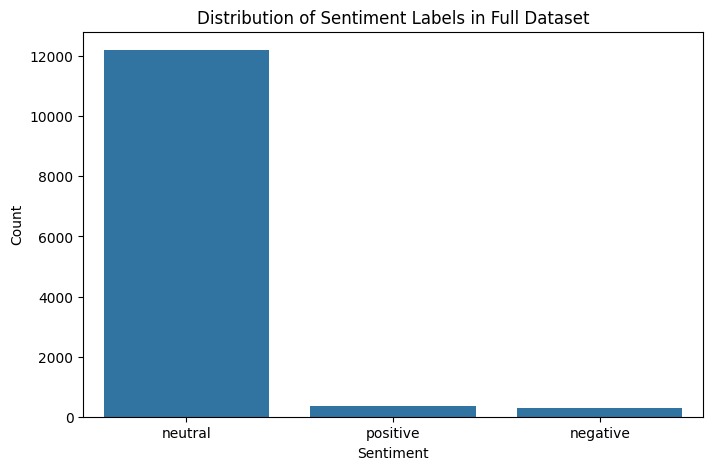

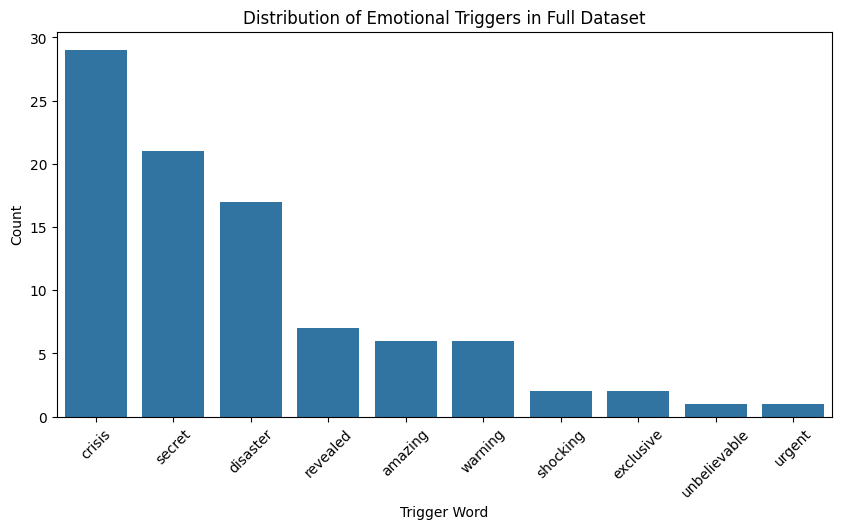

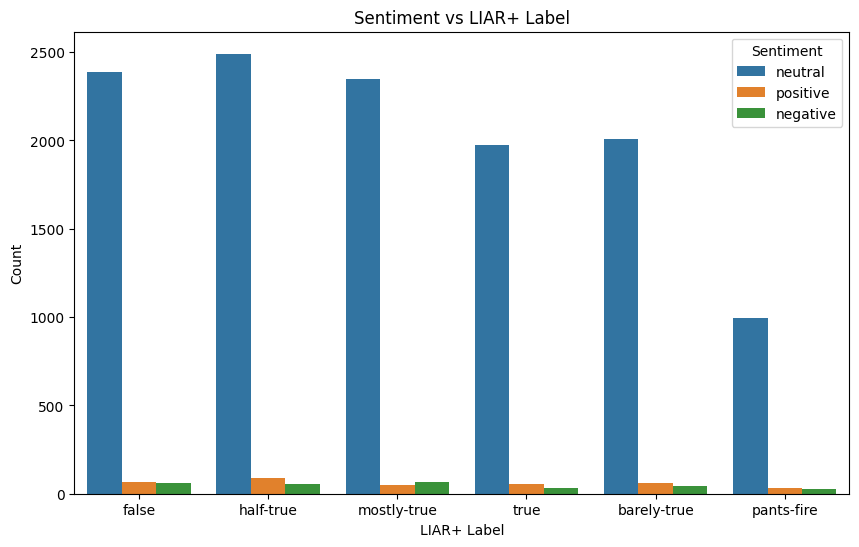

Sentiment value counts:
sentiment
neutral     12202
positive      350
negative      284
Name: count, dtype: int64

Emotional trigger counts:
emotional_triggers
crisis          29
secret          21
disaster        17
revealed         7
amazing          6
warning          6
shocking         2
exclusive        2
unbelievable     1
urgent           1
Name: count, dtype: int64

LIAR+ label counts:
label
half-true      2638
false          2511
mostly-true    2466
barely-true    2108
true           2063
pants-fire     1050
Name: count, dtype: int64


In [16]:
# --- Sentiment Analysis and Visualization for Full Dataset ---
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all splits into one DataFrame for analysis
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# If embeddings and model predictions are available, use them. For demonstration, use sentiment labels.
# Example: Distribution of sentiment labels
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=full_df, order=full_df['sentiment'].value_counts().index)
plt.title('Distribution of Sentiment Labels in Full Dataset')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Example: Distribution of emotional triggers
trigger_counts = full_df['emotional_triggers'].explode().value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=trigger_counts.index, y=trigger_counts.values)
plt.title('Distribution of Emotional Triggers in Full Dataset')
plt.xlabel('Trigger Word')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Example: Sentiment vs Label (original LIAR+ label)
plt.figure(figsize=(10, 6))
sns.countplot(x='label', hue='sentiment', data=full_df)
plt.title('Sentiment vs LIAR+ Label')
plt.xlabel('LIAR+ Label')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.show()

# Example: Print some basic stats
print('Sentiment value counts:')
print(full_df['sentiment'].value_counts())
print('\nEmotional trigger counts:')
print(trigger_counts)
print('\nLIAR+ label counts:')
print(full_df['label'].value_counts())